## Positive Classification
This is the inverse of the toxic comment classification notebook created previously.
Most of the code is reused with changes to the variable names being the main difference. 
The code has also be condensed down to strictly necessary functions as opposed to the toxic comment classification. 
This removed all the emoji processing and some print statements.
It also uses the same dataset "Youtube Comments Data - Doctor Mike VS 20 Anti-Vaxxers | Surrounded - Jubilee by Manjit Baishya on Kaggle"

In [1]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import torch
from transformers import pipeline
from tqdm.notebook import tqdm

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Leo
[nltk_data]     H\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
df = pd.read_csv('comments.csv')

In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = nltk.sentiment.SentimentIntensityAnalyzer()


positive_comments = []
neutral_comments = []
negative_comments = []

def get_sentiment(comment):
    score = sia.polarity_scores(comment)
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

for comment in df['comment']:
    sentiment = get_sentiment(comment)
    if sentiment == 'positive':
        positive_comments.append(comment)
    elif sentiment == 'negative':
        negative_comments.append(comment)
    else:
        neutral_comments.append(comment)
        
df['sentiment'] = df['comment'].apply(get_sentiment)
        
labels = [get_sentiment(comment) for comment in df['comment']]

In [7]:
#positive comment classification

positive_df = df[df['sentiment'] == 'positive']
print(positive_df.head())

device = 0 if torch.cuda.is_available() else -1

praise_model = pipeline("text-classification",
                        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                        device=device)

emotion_model = pipeline("text-classification",
                         model="j-hartmann/emotion-english-distilroberta-base",
                         device=device)

texts = positive_df["comment"].astype(str).tolist()
batch_size = 32
max_length = 128

chunks = [texts[i:i+batch_size] for i in range(0, len(texts), batch_size)]


praise_outputs = []
emotional_outputs = []

for chunk in tqdm(chunks, desc="Batches"):
    p_out = praise_model(chunk, truncation=True, max_length=max_length, batch_size=len(chunk))
    e_out = emotion_model(chunk, truncation=True, max_length=max_length, batch_size=len(chunk))

    praise_outputs.extend([o[0] if isinstance(o, list) else o for o in p_out])
    emotional_outputs.extend([o[0] if isinstance(o, list) else o for o in e_out])

res = pd.DataFrame({
    "praise_label": [o["label"] for o in praise_outputs],
    "praise_score": [o["score"] for o in praise_outputs],
    "emotion":    [o["label"] for o in emotional_outputs],
    "emotion_score":[o["score"] for o in emotional_outputs],
})
positive_df = positive_df.reset_index(drop=True).join(res)

positive_df.to_csv("positive_comments_with_labels.csv", index=False)

praise_model.model.save_pretrained("praise_model")
praise_model.tokenizer.save_pretrained("praise_tokenizer")
emotion_model.model.save_pretrained("emotion_model")
emotion_model.tokenizer.save_pretrained("emotion_tokenizer")



                                              comment sentiment
2   Compare Doctor Mike and Sam Seder to Jordan Pe...  positive
12  "I would say that correlation does not equal c...  positive
15  There’s no absolute truth period Mike?    Do y...  positive
18  the fact checks on the red haired girl where b...  positive
20  It's fairly obvious that he means that what is...  positive


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

c:\Users\Leo H\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Leo H\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/647 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_tokenizer\\tokenizer_config.json',
 'emotion_tokenizer\\tokenizer.json')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

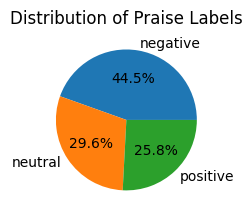

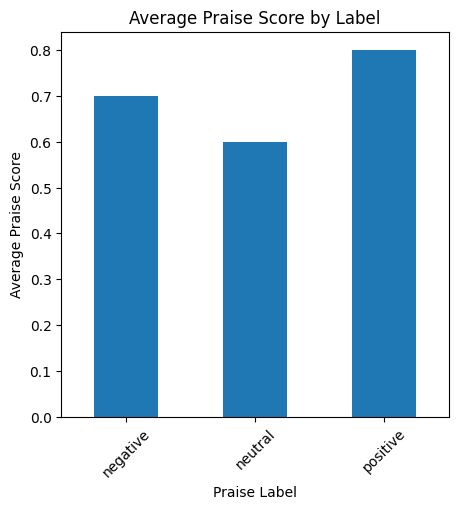

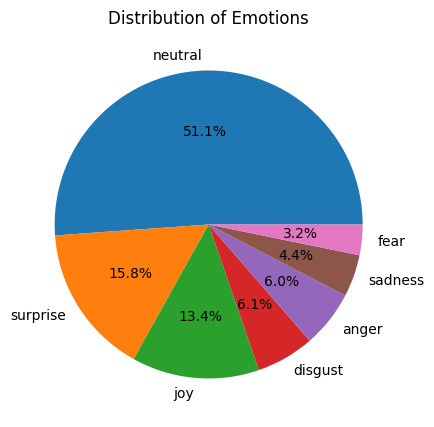

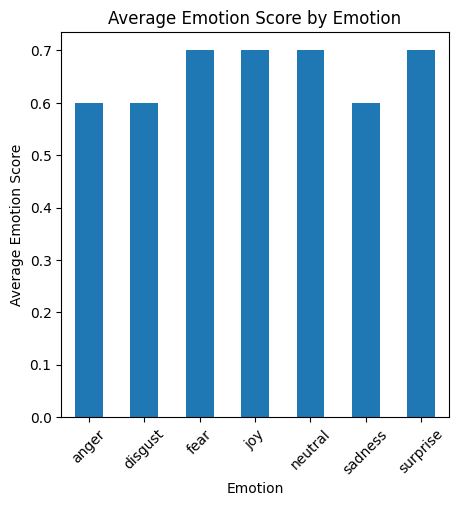

In [8]:
device = 0 if torch.cuda.is_available() else -1

praise_model = pipeline("text-classification",
						model="./praise_model",
						tokenizer="./praise_tokenizer",
						device=device)

positive_df = pd.read_csv("positive_comments_with_labels.csv")

#praise label distribution

praise_label_counts = positive_df['praise_label'].value_counts()

plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
praise_label_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Praise Labels')
plt.ylabel('')

#praise score by label
praise_score_by_label = positive_df.groupby('praise_label')['praise_score'].mean().round(1)

plt.figure(figsize=(5, 5))
praise_score_by_label.plot(kind='bar')
plt.title('Average Praise Score by Label')
plt.xlabel('Praise Label')
plt.ylabel('Average Praise Score')
plt.xticks(rotation=45)
plt.show()


#emotion count distribution

emotion_counts = positive_df['emotion'].value_counts()

plt.figure(figsize=(5, 5))
emotion_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Emotions')
plt.ylabel('')
plt.show()

#emotion score by emotion
emotion_score_by_emotion = positive_df.groupby('emotion')['emotion_score'].mean().round(1)

plt.figure(figsize=(5, 5))
emotion_score_by_emotion.plot(kind='bar')
plt.title('Average Emotion Score by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Average Emotion Score')
plt.xticks(rotation=45)
plt.show()
